In [1]:
import torch
import matplotlib.pyplot as plt


def soft_threshold(x, threshold):
    return torch.sign(x) * torch.clamp(torch.abs(x) - threshold, min=0.0)


def fista_lasso(
    X,
    y,
    lam,
    max_iter=100,
    tol=1e-6,
    device="cpu",
    verbose=False,
    lr=None,
    return_history=False,
) -> dict:
    X = torch.as_tensor(X, dtype=torch.float32, device=device)
    y = torch.as_tensor(y, dtype=torch.float32, device=device)

    if y.ndim == 2 and y.shape[1] == 1:
        y = y[:, 0]

    n, d = X.shape

    w = torch.zeros(d, dtype=torch.float32, device=device)
    z = w.clone()
    t = torch.tensor(1.0, dtype=torch.float32, device=device)

    # Lipschitz定数 L = ||X||_2^2 / n
    if lr is None:
        if verbose:
            print("Computing Lipschitz constant...")
        smax = torch.linalg.norm(X, ord=2)
        L = (smax * smax) / n
        lr = 1.0 / L
        if verbose:
            print(f"Lipschitz constant: {L:.4f}, Learning rate: {lr:.4f}")


    history = []

    for k in range(max_iter):
        grad = X.T @ (X @ z - y) / n
        w_new = soft_threshold(z - lr * grad, lr * lam)

        t_new = (1.0 + torch.sqrt(1.0 + 4.0 * t * t)) / 2.0
        z = w_new + ((t - 1.0) / t_new) * (w_new - w)
        t = t_new

        diff = torch.norm(w_new - w)
        w = w_new

        residual = X @ w - y
        loss_smooth = 0.5 * torch.sum(residual * residual) / n
        loss_l1 = lam * torch.sum(torch.abs(w))
        obj = loss_smooth + loss_l1

        if return_history:
            history.append(obj.item())

        if verbose and k % 10 == 0:
            print(
                f"Iter {k}: Objective={obj.item():.4f}, Loss={loss_smooth.item():.4f}, L1={loss_l1.item():.4f}, Diff={diff.item():.4e}"
            )

        if diff.item() < tol:
            break

    if return_history:
        return {"w": w, "history": history}
    else:
        return {"w": w}

In [2]:
torch.manual_seed(0)

n = 20_000
d = n // 4
k = n // 10

X = torch.randn(n, d)
w_true = torch.zeros(d)
w_true[:k] = torch.randn(k)
y = X @ w_true + 0.1 * torch.randn(n)

lam = 0.01

# By default, the learning rate is calculated based on the Lipschitz constant.
results = fista_lasso(
    X,
    y,
    lam,
    max_iter=100,
    tol=1e-7,
    verbose=True,
    return_history=True,
)

Computing Lipschitz constant...
Lipschitz constant: 2.2469, Learning rate: 0.4451
Iter 0: Objective=250.4246, Loss=240.0318, L1=10.3928, Diff=2.1683e+01
Iter 10: Objective=15.6843, Loss=0.1173, L1=15.5670, Diff=2.6838e-01
Iter 20: Objective=15.5551, Loss=0.1095, L1=15.4457, Diff=2.7652e-02
Iter 30: Objective=15.5548, Loss=0.1139, L1=15.4410, Diff=2.9399e-03
Iter 40: Objective=15.5548, Loss=0.1137, L1=15.4411, Diff=5.9116e-04
Iter 50: Objective=15.5548, Loss=0.1136, L1=15.4412, Diff=9.4606e-05
Iter 60: Objective=15.5548, Loss=0.1136, L1=15.4412, Diff=2.4367e-05
Iter 70: Objective=15.5548, Loss=0.1136, L1=15.4412, Diff=5.2722e-06
Iter 80: Objective=15.5548, Loss=0.1136, L1=15.4412, Diff=2.3431e-06
Iter 90: Objective=15.5548, Loss=0.1136, L1=15.4412, Diff=1.3539e-06


In [3]:
# Setting the learning rate manually to 0.1.
results2 = fista_lasso(
    X,
    y,
    lam,
    max_iter=100,
    tol=1e-7,
    verbose=True,
    lr=0.1,
    return_history=True,
)

Iter 0: Objective=747.1927, Loss=744.8575, L1=2.3351, Diff=4.8718e+00
Iter 10: Objective=29.1284, Loss=12.7684, L1=16.3599, Diff=2.1878e+00
Iter 20: Objective=16.7285, Loss=0.5910, L1=16.1375, Diff=4.1978e-01
Iter 30: Objective=15.6940, Loss=0.2446, L1=15.4493, Diff=2.1507e-01
Iter 40: Objective=15.5870, Loss=0.1581, L1=15.4288, Diff=8.6300e-02
Iter 50: Objective=15.5634, Loss=0.1042, L1=15.4592, Diff=3.6452e-02
Iter 60: Objective=15.5568, Loss=0.1244, L1=15.4324, Diff=2.2626e-02
Iter 70: Objective=15.5555, Loss=0.1124, L1=15.4431, Diff=1.3047e-02
Iter 80: Objective=15.5551, Loss=0.1131, L1=15.4420, Diff=7.1268e-03
Iter 90: Objective=15.5549, Loss=0.1148, L1=15.4401, Diff=4.6770e-03


In [4]:
w_hat = results["w"]

print("estimated w:")
print(w_hat)

print("mse:", torch.mean((w_hat - w_true) ** 2).item())
print(
    "cosine similarity:",
    torch.nn.functional.cosine_similarity(w_hat, w_true, dim=0).item(),
)
print("non-zero count:", torch.sum(w_hat != 0).item())
print("true non-zero count:", torch.sum(w_true != 0).item())

estimated w:
tensor([-0.9860, -1.1972, -0.2637,  ..., -0.0000, -0.0000,  0.0000])
mse: 5.346744728740305e-05
cosine similarity: 0.9999699592590332
non-zero count: 1993
true non-zero count: 2000


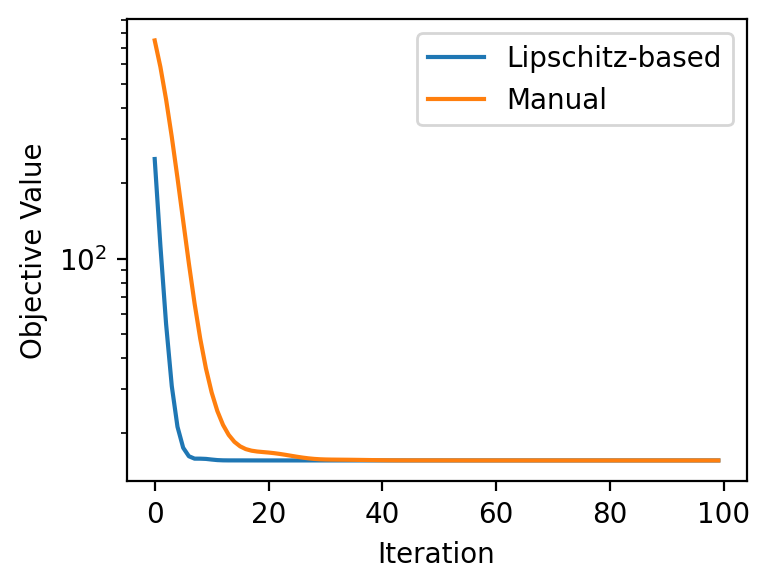

In [5]:
history = results["history"]
history2 = results2["history"]

fig = plt.figure(figsize=(4,3), dpi=200)
ax = fig.add_subplot()
ax.plot(history, label="Lipschitz-based")
ax.plot(history2, label="Manual")
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective Value")
ax.set_yscale("log")
ax.legend()
plt.show()